# Week 3 M2-N1 : Least Squares
#### Due April 18 by midnight 
#### please submit the printed notebook (.pdf) and the notebook (.ipynb) itself on gradescope


This exercise is on least squares and has five parts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import pinv
import numpy.linalg as la
from numpy.polynomial.polynomial import polyvander
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#### Please put down your name(s) here: (you must enter your team members' names on gradescope too)

\[ Your name \]

## Part I: Warmup; Least Squares with 2d synthetic data

We will start with a simple least squares example on synthetic data with the goal of visualization.

(a) Create a vector of inputs x with 201 regularly-spaced entries between 0 and 2. 

Create a vector of labels y = 1 + x + e, where e is drawn from a gaussian distribution with 0 mean and standard deviation of 0.1

In [2]:
#Todo: Part a
x = np.linspace(0, 2, 201)
y = 1 + x + 0.2 * np.random.randn(len(x))

(b) Create a matrix A whose first column is the vector x above, and it's second column is the ones vector.

In [3]:
# TODO Part (b): Assemble matrix A
A = np.array((x,np.ones(len(x)))).T

(c) Solve the ordinary least squares problem to obtain a vector w of coefficients. Print the vector 'w'. Use `numpy.linalg.pinv` to find pseudo inverse and remember the matrix operations from Week 1.

In [4]:
# TODO: Part (c)
w = (np.linalg.inv(A.T @ A) @ A.T) @ y
print(w)

[1.03715463 0.99249599]


(d) Plot the training data (x,y) as blue dots and the learned function as a red line

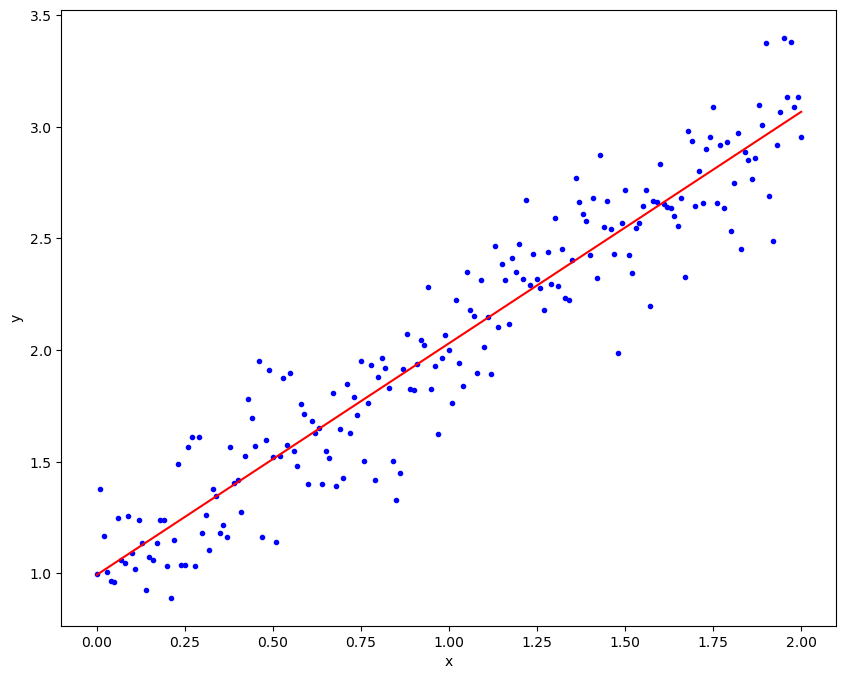

In [5]:
# TODO: Part (d)
plt.figure(figsize = (10,8))
plt.plot(x, y, 'b.')
plt.plot(x, w[0]*x + w[1], 'r')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Part II: Least Squares Regression on Real Data

In this part, we'll apply least squares to a real-world dataset: the California Housing dataset. This dataset contains information about housing in California districts, and we'll use it to predict median house values based on various features.

The dataset includes features such as:
- MedInc: median income in block group
- HouseAge: median house age in block group
- AveRooms: average number of rooms per household
- AveBedrms: average number of bedrooms per household
- Population: block group population
- AveOccup: average number of household members
- Latitude: block group latitude
- Longitude: block group longitude

Our goal is to build a linear model to predict the median house value.

(a) Load the California Housing dataset, split it into training and test sets (80/20 split with random_state=42), and standardize the features using StandardScaler. Print the shapes of the training and test sets.

In [6]:
# TODO: Part (a)
# Load the dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")

Training set shape: (16512, 8)
Test set shape: (4128, 8)
Training labels shape: (16512,)
Test labels shape: (4128,)


(b) Add a column of ones to the scaled training and test feature matrices to account for the bias term. Then solve the least squares problem using the normal equations to find the weight vector w. Print the shape of w.

In [7]:
# TODO: Part (b)
# Add bias term (column of ones)
X_train_with_bias = np.column_stack([X_train_scaled, np.ones(len(X_train_scaled))])
X_test_with_bias = np.column_stack([X_test_scaled, np.ones(len(X_test_scaled))])

# Solve least squares using normal equations: w = (X^T X)^(-1) X^T y
w = np.linalg.inv(X_train_with_bias.T @ X_train_with_bias) @ X_train_with_bias.T @ y_train

print(f"Weight vector shape: {w.shape}")
print(f"Weights: {w}")

Weight vector shape: (9,)
Weights: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178  2.07194694]


(c) Compute predictions on both training and test sets. Calculate the Root Mean Square Error (RMSE) for both sets and print them. The RMSE is defined as:

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

In [8]:
# TODO: Part (c)
# Make predictions
y_train_pred = X_train_with_bias @ w
y_test_pred = X_test_with_bias @ w

# Calculate RMSE
train_rmse = np.sqrt(np.mean((y_train - y_train_pred)**2))
test_rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Training RMSE: 0.7197
Test RMSE: 0.7456


(d) Create a scatter plot showing the actual vs predicted values for the test set. Plot a red diagonal line representing perfect predictions (y = x). Label the axes appropriately and add a grid.

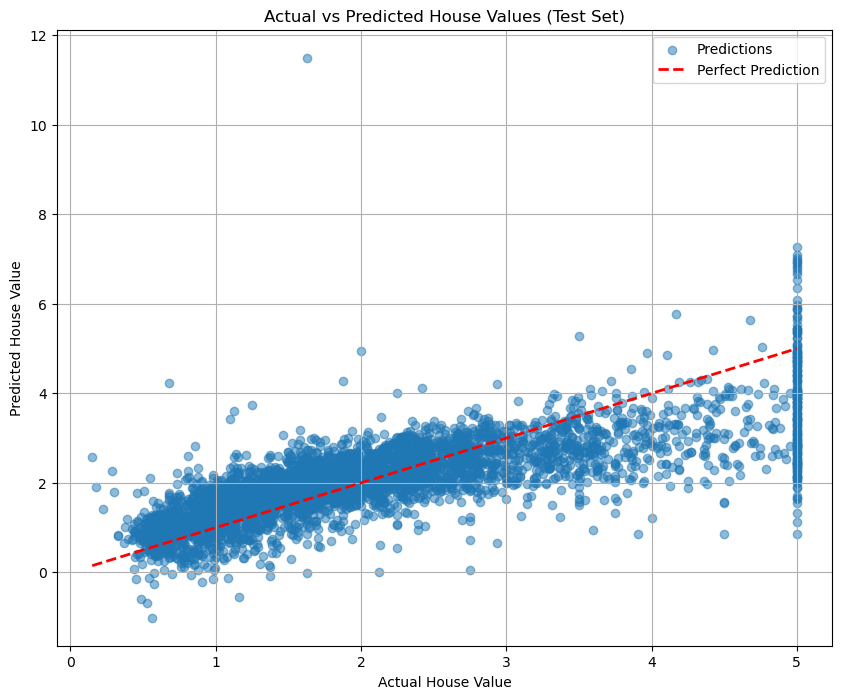

In [9]:
# TODO: Part (d)
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Values (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

## Part III:  Interpolation of rational functions (VMLS 8.8)

Refer to Problem 8.8 of VMLS:

"A rational function of degree two has the form

$$
f(t) = \frac{c_1 + c_2t + c_3t^2}{1 + d_1t + d_2t^2},
$$

where $ c_1, c_2, c_3, d_1, d_2 $ are coefficients. ('Rational' refers to the fact that $ f $ is a ratio of polynomials. Another name for $ f $ is bi-quadratic.) Consider the interpolation conditions

$$
f(t_i) = y_i, \quad i = 1, \ldots, K,
$$

where $ t_i $ and $ y_i $ are given numbers. Express the interpolation conditions as a set of linear equations in the vector of coefficients $ \theta = (c_1, c_2, c_3, d_1, d_2) $, as $ A\theta = b $. Give $ A $ and $ b $, and their dimensions.
"

You are provided with $K=50$ datapoints of form $(t,f(t))$. Read the data, implement a least square solution to find the coefficients $c_1, c_2, c_3, d_1, d_2$. Print the coefficients. Consider the interval $t \in [-3,3]$, plot the data points (scatter plot) and the fitted rational function (line plot) on the same graph to visualize the fit. 

c1: 8.02804108111243
c2: 32.40274700761303
c3: 1871.1419473919138
d1: 3.900278346361235
d2: 16.641260451457832


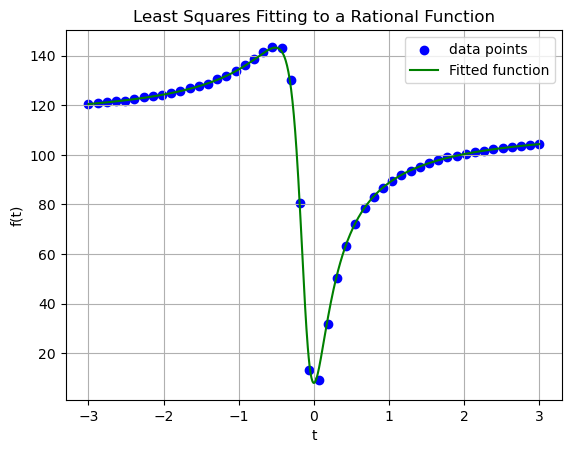

In [10]:
# Load the data from the file
data = np.load('rational_function_data.npz')
t_values = data['t']
f_values = data['f']

# Create matrices A and b
A = np.zeros((len(t_values), 5))
b = f_values

for i, t in enumerate(t_values):
    A[i, :] = [t**2, t, 1, -f_values[i]*t**2, -f_values[i]*t]

# Solve for the coefficients using the pseudo-inverse
coefficients = pinv(A) @ b

# Print individual coefficients
c1, c2, c3, d1, d2 = coefficients[2], coefficients[1], coefficients[0], coefficients[4], coefficients[3]
print(f'c1: {c1}')
print(f'c2: {c2}')
print(f'c3: {c3}')
print(f'd1: {d1}')
print(f'd2: {d2}')

# Function f
def f(t, c1, c2, c3, d1, d2):
    return (c1 + c2 * t + c3 * t**2) / (1 + d1 * t + d2 * t**2)

# Plot the data
plt.scatter(t_values, f_values, label='data points', color='blue')

# Plot the fitted rational function using the estimated coefficients
t_fit = np.linspace(min(t_values), max(t_values), 1000)
f_fit = f(t_fit, c1, c2, c3, d1, d2)
plt.plot(t_fit, f_fit, label='Fitted function', color='green')

# Label the plot
plt.title('Least Squares Fitting to a Rational Function')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.legend()

# Show the plot with grid
plt.grid(True)
plt.show()


## Part IV: System Identification

Making autonomous vehicles involves machine learning for different purposes. One of which is learning how cars actually behave based on their data.

**Setup for part IV :** Assume that $x_t$ is the position of a car and obeys the following linear dynamics $$x_{t+1} = A^* x_t + B^* u_t $$

We do not know the matrices $A^*$ and $B^*$. But we have data about the cars position for timesteps $1 \ldots T$. We want to use this data to infer the underlying dynamics.

(a) Consider the time sequences of vectors $x_t \in \mathbb{R}^3$ and $u_t \in \mathbb{R}^3$ in which $x_{t + 1} ≈ Ax_t + Bu_t$ . In control theory, $x_t$ usually represents the state, and $u_t$ usually represents the control input. Find and output the matrix $A \in \mathbb{R}^{3×3}$ and $B \in \mathbb{R}^{3×3}$ so that the sum of the squared $l_2$-norms of the error, 
$$\sum_t \| x_{t+1} − A x_t −B u_t \|_2^2 $$
is minimized. The values of x_t and u_t are stored in `data.npz`.

In [11]:
with np.load("data.npz") as data:
    x = data['x']
    u = data['u']

Print the matrices $A, B$. 

**Note:** Write this down as a familiar $MX ≈ N$ least squares problem where $M$ and $N$ are known. Let $X^*$ be the solution to this least square problem. Correctly identify your $A$ and $B$ matrices from $X^*$. Incorrect identification during this step will lead to incorrect validation in the next steps. 

In [12]:
# TODO: Your code to compute A, B
M = np.concatenate((x[:-1],u[:-1]), axis=1)
y= x[1:]
w = (np.linalg.inv(M.T @ M) @ M.T) @ y
print(w)

[[ 0.1490436   0.93429603 -0.00924671]
 [ 0.03691352  0.30659627  0.86673087]
 [-0.51552362  0.06695391 -0.46390307]
 [ 0.50218253  0.21749695 -0.06070802]
 [-0.07014935 -0.97394415  0.10483383]
 [ 0.11284326 -0.43242355  0.85501395]]


#### Validation:
(b) The data for validation is stored in `data_val.npz`. Load the validation data. (this is an easy task)

In [13]:
# TODO: Your code to load the validation data from ls_val.mat
with np.load("data_val.npz") as data:
    x = data['x']
    u = data['u']

(c) Using $u_t$ and the just initial value of x: $x_0$, find $x_t$ for the rest of the times using the linear model $x_{t+1} = A x_t + B u_t $. Collect these values in an array called 'x_hat'. 

In [14]:
# TODO: Your code to find x_hat
x_hat = [x[0]]
for u_i in u[:-1]:
    x_hat.append( (w[0:3].T @ x_hat[-1]) + (w[3:].T @u_i))

x_hat = np.array(x_hat)

(d) Find the square of the rms of the error and the rms of the state $x_t$ (not x_hat) the following way

$$e = \sum_t \frac{1}{T} \left\| \hat{x}_t - x_t\right\|^2$$
$$p =  \sum_t \frac{1}{T}\left\|  x_t\right\|^2$$


Print $e,p$ and $e/p$. (To verify your answer, $e/p$ has to be in the order of $10^{-3}$)

In [15]:
# TODO: Your code find e,p,e/p
e = np.sum((x_hat.flatten() - x.flatten())**2)
p =np.sum(( x.flatten())**2)
print(e,p,e/p)

0.5496853110170421 393.3722216884863 0.001397366872163996
